In [8]:
import pandas as pd

with open("AL-VIDRIO-MVSH-300K.DAT", "r", encoding="latin-1") as f:
    data = f.read()

data

'[Header]\n; VSM Data File (default extension .dat)\n; Copyright (c) 2003-2013, Quantum Design, Inc. All rights reserved.\nTITLE,MEDIDAS MVSH - GRUPO AL/VIDRIO\nFILEOPENTIME,25905752.19,11/20/2025,11:31 am\nBYAPP,VSM,2.0,2.0\nINFO,PPMS VSM Option Release 1.4.10 Build 1,APPNAME\nINFO,Quantum Design Linear Motor Servo Controller,MOTOR_MODULE_NAME\nINFO,3101-100 E1,MOTOR_HW_VERSION\nINFO,MMC271,MOTOR_SERIAL_NUMBER\nINFO,SRV No X-over 01.01.11,MOTOR_SOFTWARE_VERSION\nINFO,Quantum Design VSM Detection Module,VSM_MODULE_NAME\nINFO,3101-150 D1,VSM_HW_VERSION\nINFO,250,VSM_SERIAL_NUMBER\nINFO,VSM No X-over 01.02.05 May 20 2008 13:51:47,VSM_SOFTWARE_VERSION\nINFO,259,PREAMP_SERIAL_NUMBER\nINFO,320,COIL_SERIAL_NUMBER\nINFO,0,MOMENT_UNITS\nINFO,Aluminio puro,SAMPLE_MATERIAL\nINFO,Pelicula delgada de Al/vidrio,SAMPLE_COMMENT\nINFO,,SAMPLE_MASS\nINFO,,SAMPLE_VOLUME\nINFO,,SAMPLE_MOLECULAR_WEIGHT\nINFO,3.44mm x 4.38mm,SAMPLE_SIZE\nINFO,Rectangular,SAMPLE_SHAPE\nDATATYPE,COMMENT,1\nDATATYPE,TIME,2\nS

In [9]:
import pandas as pd

# Encontrar el índice donde empieza la sección de datos
with open("AL-VIDRIO-MVSH-300K.DAT", "r", encoding="latin-1") as f:
    lines = f.readlines()

# Ubicar la línea que dice "[Data]"
start_index = None
for i, line in enumerate(lines):
    if line.strip() == "[Data]":
        start_index = i + 1   # los encabezados están en la línea siguiente
        break

# Cargar solo los datos a partir del encabezado CSV
df = pd.read_csv(
    "AL-VIDRIO-MVSH-300K.DAT",
    skiprows=start_index,
    encoding="latin-1"
)

df.head()


,Comment,Time Stamp (sec),Temperature (K),Magnetic Field (Oe),Moment (emu),M. Std. Err. (emu),Transport Action,Averaging Time (sec),Frequency (Hz),Peak Amplitude (mm),...,Map 20 (),Map 21 (),Map 22 (),Map 23 (),Map 24 (),Map 25 (),Map 26 (),Map 27 (),Map 28 (),Map 29 ()
0,NaN,2.590580e+07,300.026276,6269.0590,NaN,NaN,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,300.026276,NaN,NaN,NaN,NaN
1,NaN,2.590583e+07,300.027573,10000.1335,-0.000009,1.328873e-06,1,0.999253,40.029888,1.999309,...,NaN,NaN,NaN,NaN,NaN,300.027573,NaN,NaN,NaN,NaN
2,NaN,2.590585e+07,300.024841,9939.0460,-0.000009,2.324507e-06,1,0.999253,40.029888,1.999458,...,NaN,NaN,NaN,NaN,NaN,300.024841,NaN,NaN,NaN,NaN
3,NaN,2.590585e+07,300.024994,9891.0680,-0.000009,8.088623e-07,1,0.999253,40.029888,1.999539,...,NaN,NaN,NaN,NaN,NaN,300.024994,NaN,NaN,NaN,NaN
4,NaN,2.590585e+07,300.024902,9815.7140,-0.000008,9.415079e-07,1,0.999253,40.029888,1.999539,...,NaN,NaN,NaN,NaN,NaN,300.024902,NaN,NaN,NaN,NaN


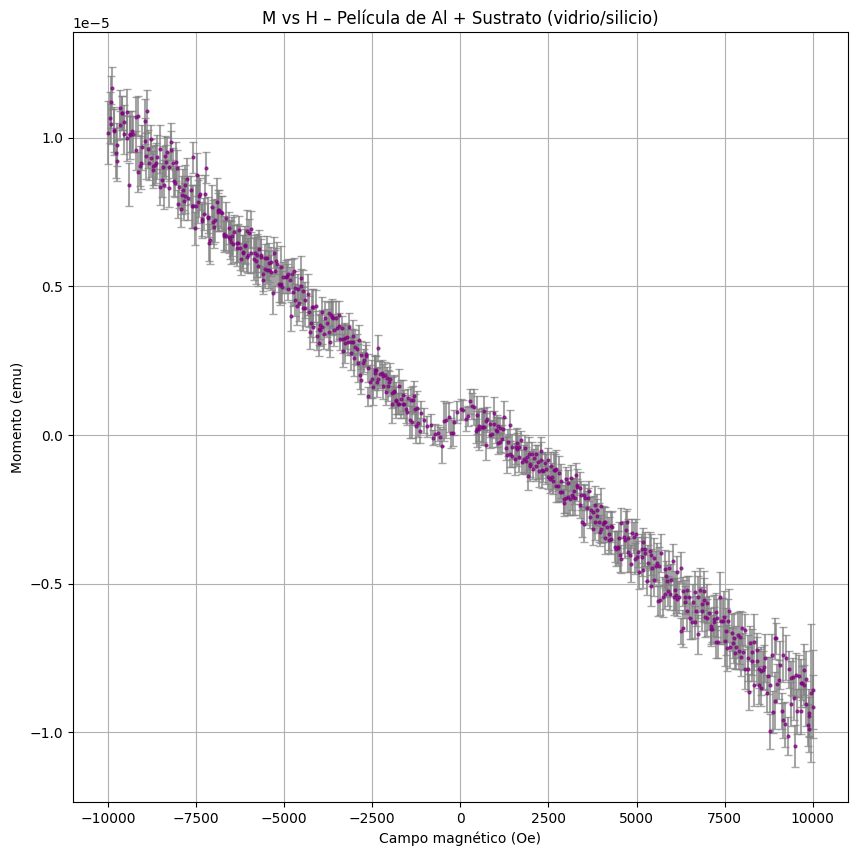

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

# Gráfico con barras de error
plt.errorbar(
    df["Magnetic Field (Oe)"],
    df["Moment (emu)"],
    yerr=df["M. Std. Err. (emu)"],
    fmt='o',
    markersize=2,
    alpha=0.7,
    ecolor='gray',
    capsize=3,
    color='purple'
)

plt.xlabel("Campo magnético (Oe)")
plt.ylabel("Momento (emu)")
plt.title("M vs H – Película de Al + Sustrato (vidrio/silicio)")
plt.grid(True)
plt.show()


In [11]:
#intervalo lineal
mask = df["Magnetic Field (Oe)"] < -2500
branch = df[mask]

In [12]:
import numpy as np

H = branch["Magnetic Field (Oe)"].values
M = branch["Moment (emu)"].values
E = branch["M. Std. Err. (emu)"].values

coef = np.polyfit(H, M, 1)  # ajuste lineal M = a·H + b
pendiente = coef[0]
intercepto = coef[1]

print("Pebndiente (susceptibilidad del sustrato) =", pendiente)
print("Intercepto =", intercepto)


Pebndiente (susceptibilidad del sustrato) = -1.133091293066544e-09
Intercepto = -5.700165313967596e-07


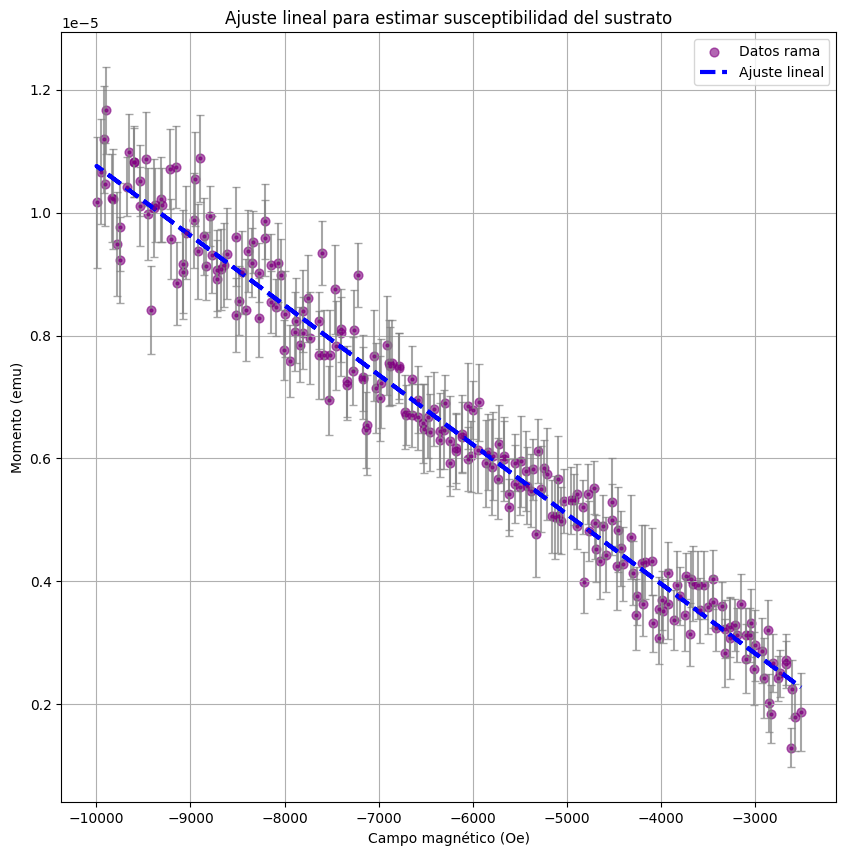

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(H, M, label="Datos rama",s=40, alpha=0.6, color='purple')
plt.errorbar(
    H,
    M,
    yerr=E,
    fmt='o',
    markersize=2,
    alpha=0.7,
    ecolor='gray',
    capsize=3,
    color='purple'
)



plt.plot(H, pendiente*H + intercepto,'--',color = "blue", label="Ajuste lineal", linewidth=3)
plt.xlabel("Campo magnético (Oe)")
plt.ylabel("Momento (emu)")
plt.title("Ajuste lineal para estimar susceptibilidad del sustrato")
plt.grid(True)
plt.legend()
plt.show()


In [14]:
susceptibilidad_sustrato = pendiente
X = pendiente   # ya calculado con polyfit


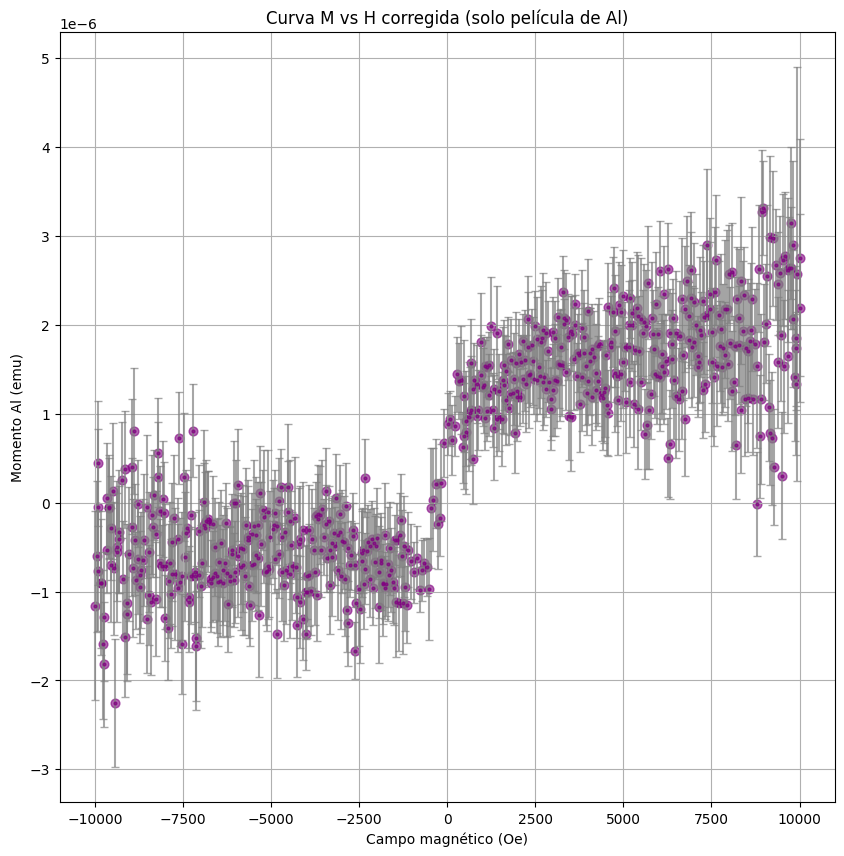

In [15]:
df["Al_moment(emu)"] = df["Moment (emu)"] - (X * df["Magnetic Field (Oe)"])
df[["Magnetic Field (Oe)", "Moment (emu)", "Al_moment(emu)"]].head()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.scatter(df["Magnetic Field (Oe)"], df["Al_moment(emu)"],s=40, alpha=0.6, color='purple')

plt.errorbar(
    df["Magnetic Field (Oe)"],
    df["Al_moment(emu)"],
    yerr=df["M. Std. Err. (emu)"],
    fmt='o',
    markersize=2,
    alpha=0.7,
    ecolor='gray',
    capsize=3,
    color='purple'
)


plt.xlabel("Campo magnético (Oe)")
plt.ylabel("Momento Al (emu)")
plt.title("Curva M vs H corregida (solo película de Al)")
plt.grid(True)
plt.show()


Parámetros de la película:
  Espesor: 1.5 nm = 1.50e-07 cm
  Área: 9.415108 cm²
  Volumen: 1.41e-06 cm³

Datos totales: 600
Datos después de eliminar NaN: 598
NaN eliminados: 2

Filtrado de outliers:
  Datos originales: 598
  Datos después de filtrar: 598
  Outliers removidos: 0

Pesos calculados basados en densidad KDE

AJUSTE CON FUNCIÓN DE LANGEVIN

Parámetros del ajuste de Langevin:
  Ms (Magnetización de saturación): 9.2124e-01 ± 1.88e-02 emu/cm³
  a (parámetro): 2.3599e-03 ± 2.92e-04 Oe⁻¹
  M0 (offset): 3.8981e-01 ± 1.07e-02 emu/cm³
  Momento magnético efectivo μ: 7.7784e-18 emu
  R² del ajuste: 0.882443
  RMSE: 3.4580e-01 emu/cm³

AJUSTE CON FUNCIÓN DE BRILLOUIN

Parámetros del ajuste de Brillouin:
  Ms (Magnetización de saturación): 8.7748e-01 ± 3.71e-02 emu/cm³
  J (Momento angular): 5.0000 ± 7.7676
  g (Factor de Landé): 3.1847 ± 0.0000
  a (parámetro): 1.9044e-03 ± 6.35e-04 Oe⁻¹
  M0 (offset): 3.9038e-01 ± 1.08e-02 emu/cm³
  R² del ajuste: 0.881508
  RMSE: 3.4680e-01 emu/cm³

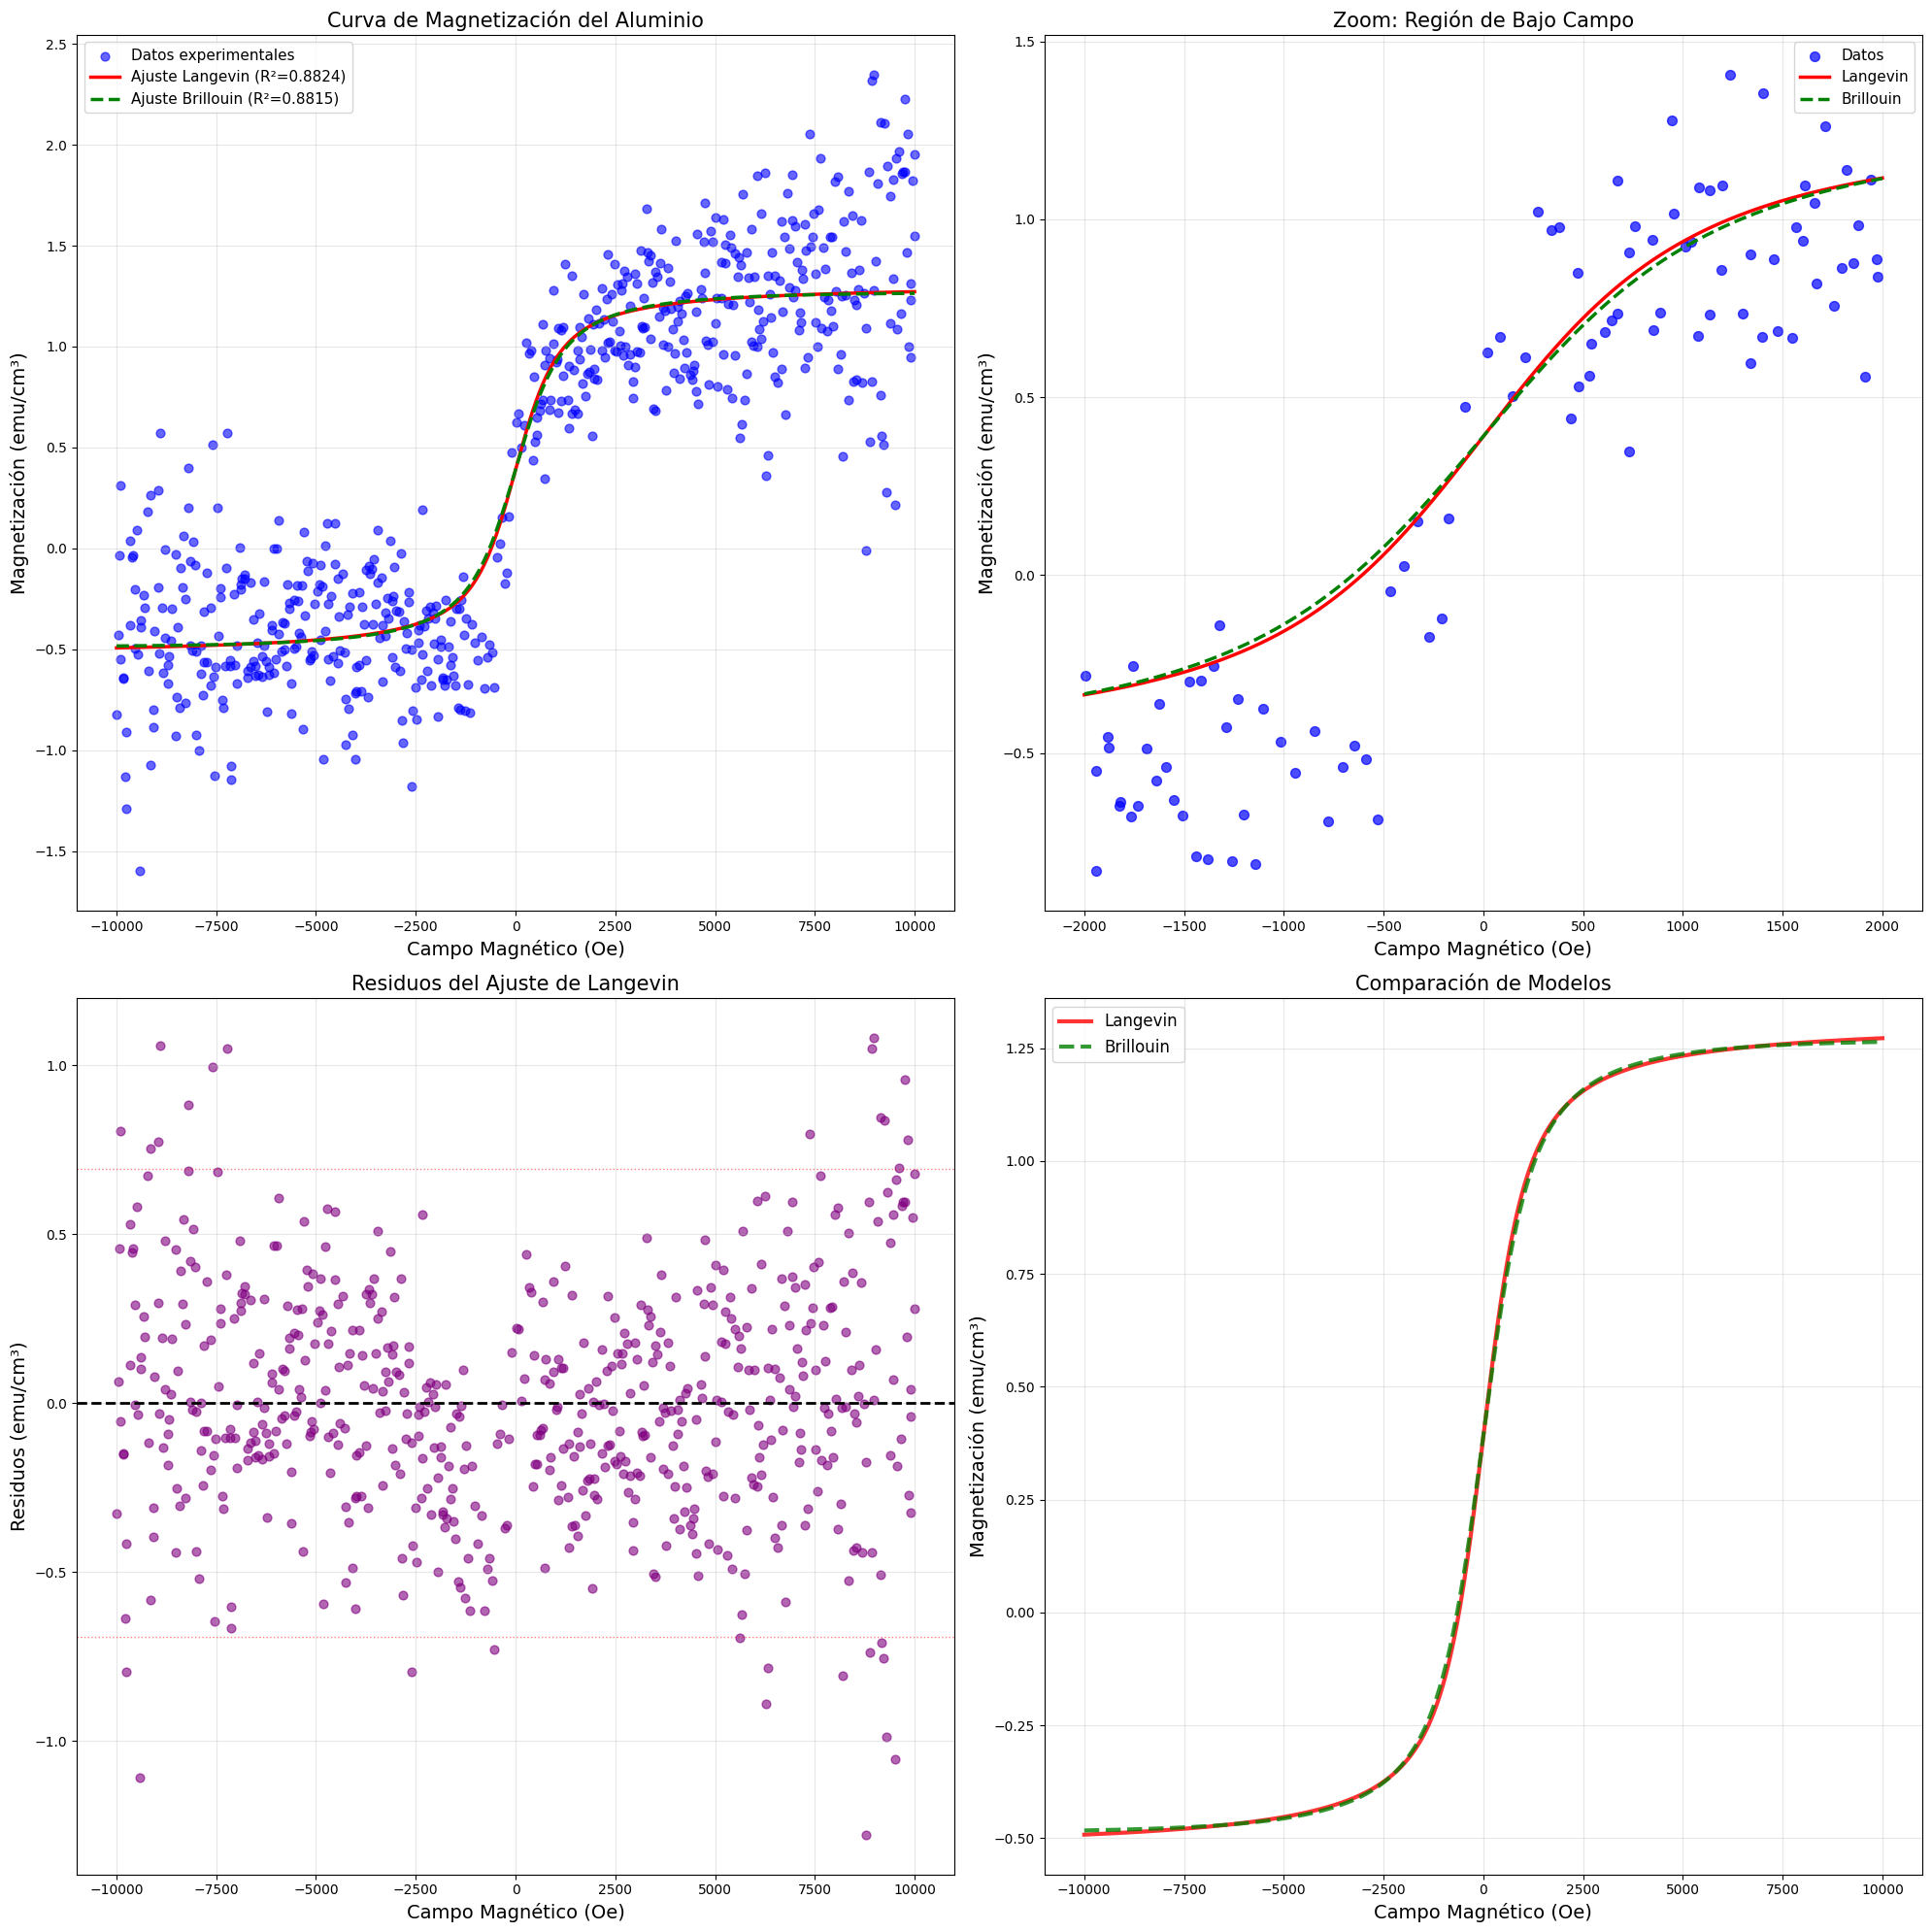


RESUMEN COMPARATIVO DE AJUSTES

Langevin:
  R² = 0.882443
  RMSE = 3.4580e-01 emu/cm³

Brillouin:
  R² = 0.881508
  RMSE = 3.4680e-01 emu/cm³

RECOMENDACIÓN:
El modelo de Langevin proporciona mejor ajuste.
Esto sugiere comportamiento superparamagnético.

INTERPRETACIÓN FÍSICA

COMPORTAMIENTO MAGNÉTICO DEL ALUMINIO:

1. NATURALEZA DEL MAGNETISMO:
   - El aluminio puro es PARAMAGNÉTICO a temperatura ambiente
   - Susceptibilidad magnética positiva pero muy pequeña (χ ≈ 2.2 × 10⁻⁵)
   - No presenta orden magnético a largo alcance

2. MODELO DE LANGEVIN:
   - Apropiado para partículas superparamagnéticas o nanopartículas
   - Si el ajuste es bueno, sugiere presencia de clusters magnéticos
   - El parámetro 'a' está relacionado con el tamaño de las partículas

3. MODELO DE BRILLOUIN:
   - Más apropiado para iones con momento angular bien definido
   - Para Al³⁺, J=0 (capa cerrada), pero impurezas o defectos pueden contribuir
   - El valor de J obtenido indica el tipo de centros magnéticos


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.constants import k as k_B, mu_0

# ============================================================================
# PARÁMETROS DE LA PELÍCULA (Ajusta estos valores según tus datos)
# ============================================================================
espesor_nm = 1.5  # Espesor en nanómetros
area_cm2 = 2.546*3.698  # Área en cm²

# Calcular volumen
espesor_cm = espesor_nm * 1e-7  # Convertir nm a cm
volumen_cm3 = area_cm2 * espesor_cm

print(f"Parámetros de la película:")
print(f"  Espesor: {espesor_nm} nm = {espesor_cm:.2e} cm")
print(f"  Área: {area_cm2} cm²")
print(f"  Volumen: {volumen_cm3:.2e} cm³")
print("="*70)

# ============================================================================
# CARGAR Y PREPARAR DATOS
# ============================================================================
df_clean = df[["Magnetic Field (Oe)", "Al_moment(emu)"]].dropna()
print(f"\nDatos totales: {len(df)}")
print(f"Datos después de eliminar NaN: {len(df_clean)}")
print(f"NaN eliminados: {len(df) - len(df_clean)}")

# Convertir momento magnético a magnetización (emu/cm³)
magnetizacion = df_clean["Al_moment(emu)"].values / volumen_cm3
campo_Oe = df_clean["Magnetic Field (Oe)"].values

# ============================================================================
# REMOVER OUTLIERS EXTREMOS (CRÍTICO PARA MEJORAR EL AJUSTE)
# ============================================================================
# Calcular percentiles para identificar outliers
Q1 = np.percentile(magnetizacion, 25)
Q3 = np.percentile(magnetizacion, 75)
IQR = Q3 - Q1

# Límites más generosos para no perder datos válidos
limite_inferior = Q1 - 3*IQR
limite_superior = Q3 + 3*IQR

# Filtrar outliers
mask_validos = (magnetizacion >= limite_inferior) & (magnetizacion <= limite_superior)
magnetizacion_limpia = magnetizacion[mask_validos]
campo_Oe_limpio = campo_Oe[mask_validos]

print(f"\nFiltrado de outliers:")
print(f"  Datos originales: {len(magnetizacion)}")
print(f"  Datos después de filtrar: {len(magnetizacion_limpia)}")
print(f"  Outliers removidos: {len(magnetizacion) - len(magnetizacion_limpia)}")

# ============================================================================
# DEFINIR FUNCIONES DE AJUSTE
# ============================================================================

def langevin(H, Ms, a):
    """Función de Langevin para partículas superparamagnéticas"""
    x = a * H
    x = np.where(np.abs(x) < 1e-10, 1e-10, x)
    # Usar aproximación para valores pequeños para evitar inestabilidad numérica
    resultado = np.zeros_like(x)
    mask_small = np.abs(x) < 0.1
    mask_large = ~mask_small
    
    # Para x pequeño: L(x) ≈ x/3
    resultado[mask_small] = x[mask_small] / 3.0
    
    # Para x grande: L(x) = coth(x) - 1/x
    resultado[mask_large] = 1.0/np.tanh(x[mask_large]) - 1.0/x[mask_large]
    
    return Ms * resultado

def brillouin(H, Ms, J, g, a):
    """Función de Brillouin para sistemas con momento angular J"""
    x = a * H
    x = np.where(np.abs(x) < 1e-10, 1e-10, x)
    
    factor1 = (2*J + 1) / (2*J)
    factor2 = 1 / (2*J)
    
    arg1 = (2*J + 1) * x / (2*J)
    arg2 = x / (2*J)
    
    # Evitar overflow en tanh
    arg1 = np.clip(arg1, -700, 700)
    arg2 = np.clip(arg2, -700, 700)
    
    B_J = factor1 / np.tanh(arg1) - factor2 / np.tanh(arg2)
    return Ms * B_J

def langevin_con_offset(H, Ms, a, M0):
    """Langevin con offset para capturar magnetización remanente"""
    return langevin(H, Ms, a) + M0

def brillouin_con_offset(H, Ms, J, g, a, M0):
    """Brillouin con offset para capturar magnetización remanente"""
    return brillouin(H, Ms, J, g, a) + M0

# ============================================================================
# CALCULAR PESOS BASADOS EN DENSIDAD
# ============================================================================
from scipy.stats import gaussian_kde

try:
    # Estimar densidad de probabilidad de los datos
    kde = gaussian_kde(np.vstack([campo_Oe_limpio, magnetizacion_limpia]))
    densidades = kde(np.vstack([campo_Oe_limpio, magnetizacion_limpia]))
    # Normalizar pesos
    pesos = densidades / np.sum(densidades) * len(densidades)
    pesos = np.sqrt(pesos)  # Raíz cuadrada para no sobre-ponderar
    print("\nPesos calculados basados en densidad KDE")
except:
    print("\nNo se pudo calcular densidad KDE, usando pesos uniformes")
    pesos = np.ones_like(campo_Oe_limpio)

# ============================================================================
# AJUSTE CON MODELO DE LANGEVIN CON OFFSET
# ============================================================================
print("\n" + "="*70)
print("AJUSTE CON FUNCIÓN DE LANGEVIN")
print("="*70)

# Mejores estimaciones iniciales
Ms_inicial = np.percentile(np.abs(magnetizacion_limpia), 95)
a_inicial = 1.0 / np.percentile(np.abs(campo_Oe_limpio), 75)

try:
    popt_lang, pcov_lang = curve_fit(
        langevin_con_offset, 
        campo_Oe_limpio, 
        magnetizacion_limpia,
        p0=[Ms_inicial, a_inicial, 0.0],
        sigma=1.0/pesos,
        absolute_sigma=False,
        maxfev=50000,
        method='trf'
    )
    
    Ms_lang, a_lang, M0_lang = popt_lang
    errores_lang = np.sqrt(np.diag(pcov_lang))
    
    print(f"\nParámetros del ajuste de Langevin:")
    print(f"  Ms (Magnetización de saturación): {Ms_lang:.4e} ± {errores_lang[0]:.2e} emu/cm³")
    print(f"  a (parámetro): {a_lang:.4e} ± {errores_lang[1]:.2e} Oe⁻¹")
    print(f"  M0 (offset): {M0_lang:.4e} ± {errores_lang[2]:.2e} emu/cm³")
    
    # Calcular momento magnético efectivo
    T = 300  # Temperatura en K
    mu_eff = a_lang * k_B * T / mu_0
    print(f"  Momento magnético efectivo μ: {mu_eff:.4e} emu")
    
    # Calidad del ajuste
    M_ajustado_lang = langevin_con_offset(campo_Oe_limpio, *popt_lang)
    residuos_lang = magnetizacion_limpia - M_ajustado_lang
    
    # R² ponderado
    ss_res = np.sum(pesos * residuos_lang**2)
    ss_tot = np.sum(pesos * (magnetizacion_limpia - np.average(magnetizacion_limpia, weights=pesos))**2)
    R2_lang = 1 - ss_res/ss_tot
    
    # RMSE
    rmse_lang = np.sqrt(np.mean(residuos_lang**2))
    
    print(f"  R² del ajuste: {R2_lang:.6f}")
    print(f"  RMSE: {rmse_lang:.4e} emu/cm³")
    
except Exception as e:
    print(f"Error en el ajuste de Langevin: {e}")
    popt_lang = None

# ============================================================================
# AJUSTE CON MODELO DE BRILLOUIN CON OFFSET
# ============================================================================
print("\n" + "="*70)
print("AJUSTE CON FUNCIÓN DE BRILLOUIN")
print("="*70)

J_inicial = 0.5
g_inicial = 2.0

try:
    popt_brill, pcov_brill = curve_fit(
        brillouin_con_offset,
        campo_Oe_limpio,
        magnetizacion_limpia,
        p0=[Ms_inicial, J_inicial, g_inicial, a_inicial, 0.0],
        sigma=1.0/pesos,
        absolute_sigma=False,
        bounds=([0, 0.1, 0.5, 0, -np.inf], [np.inf, 5.0, 4.0, np.inf, np.inf]),
        maxfev=50000,
        method='trf'
    )
    
    Ms_brill, J_brill, g_brill, a_brill, M0_brill = popt_brill
    errores_brill = np.sqrt(np.diag(pcov_brill))
    
    print(f"\nParámetros del ajuste de Brillouin:")
    print(f"  Ms (Magnetización de saturación): {Ms_brill:.4e} ± {errores_brill[0]:.2e} emu/cm³")
    print(f"  J (Momento angular): {J_brill:.4f} ± {errores_brill[1]:.4f}")
    print(f"  g (Factor de Landé): {g_brill:.4f} ± {errores_brill[2]:.4f}")
    print(f"  a (parámetro): {a_brill:.4e} ± {errores_brill[3]:.2e} Oe⁻¹")
    print(f"  M0 (offset): {M0_brill:.4e} ± {errores_brill[4]:.2e} emu/cm³")
    
    # Calidad del ajuste
    M_ajustado_brill = brillouin_con_offset(campo_Oe_limpio, *popt_brill)
    residuos_brill = magnetizacion_limpia - M_ajustado_brill
    
    ss_res_brill = np.sum(pesos * residuos_brill**2)
    ss_tot_brill = np.sum(pesos * (magnetizacion_limpia - np.average(magnetizacion_limpia, weights=pesos))**2)
    R2_brill = 1 - ss_res_brill/ss_tot_brill
    rmse_brill = np.sqrt(np.mean(residuos_brill**2))
    
    print(f"  R² del ajuste: {R2_brill:.6f}")
    print(f"  RMSE: {rmse_brill:.4e} emu/cm³")
    
except Exception as e:
    print(f"Error en el ajuste de Brillouin: {e}")
    popt_brill = None

# ============================================================================
# VISUALIZACIÓN DE RESULTADOS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Gráfica 1: Magnetización vs Campo Magnético
ax1 = axes[0, 0]
# Mostrar datos removidos en gris
mask_outliers = ~mask_validos
if np.sum(mask_outliers) > 0:
    ax1.scatter(campo_Oe[mask_outliers], magnetizacion[mask_outliers], 
                s=20, alpha=0.3, color='gray', label='Outliers removidos')

# Datos limpios
ax1.scatter(campo_Oe_limpio, magnetizacion_limpia, s=40, alpha=0.6, 
            label='Datos experimentales', color='blue')

# Curvas de ajuste
H_fit = np.linspace(campo_Oe_limpio.min(), campo_Oe_limpio.max(), 1000)

if popt_lang is not None:
    M_fit_lang = langevin_con_offset(H_fit, *popt_lang)
    ax1.plot(H_fit, M_fit_lang, 'r-', linewidth=2.5, 
             label=f'Ajuste Langevin (R²={R2_lang:.4f})')

if popt_brill is not None:
    M_fit_brill = brillouin_con_offset(H_fit, *popt_brill)
    ax1.plot(H_fit, M_fit_brill, 'g--', linewidth=2.5, 
             label=f'Ajuste Brillouin (R²={R2_brill:.4f})')

ax1.set_xlabel('Campo Magnético (Oe)', fontsize=14)
ax1.set_ylabel('Magnetización (emu/cm³)', fontsize=14)
ax1.set_title('Curva de Magnetización del Aluminio', fontsize=15)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Zoom en región de bajo campo
ax2 = axes[0, 1]
mask_zoom = np.abs(campo_Oe_limpio) < 2000
ax2.scatter(campo_Oe_limpio[mask_zoom], magnetizacion_limpia[mask_zoom], 
            s=50, alpha=0.7, color='blue', label='Datos')

H_zoom = np.linspace(-2000, 2000, 1000)

if popt_lang is not None:
    M_zoom_lang = langevin_con_offset(H_zoom, *popt_lang)
    ax2.plot(H_zoom, M_zoom_lang, 'r-', linewidth=2.5, label='Langevin')

if popt_brill is not None:
    M_zoom_brill = brillouin_con_offset(H_zoom, *popt_brill)
    ax2.plot(H_zoom, M_zoom_brill, 'g--', linewidth=2.5, label='Brillouin')

ax2.set_xlabel('Campo Magnético (Oe)', fontsize=14)
ax2.set_ylabel('Magnetización (emu/cm³)', fontsize=14)
ax2.set_title('Zoom: Región de Bajo Campo', fontsize=15)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Gráfica 3: Residuos del ajuste de Langevin
ax3 = axes[1, 0]
if popt_lang is not None:
    ax3.scatter(campo_Oe_limpio, residuos_lang, s=40, alpha=0.6, color='purple')
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=2)
    
    # Agregar bandas de confianza
    std_residuos = np.std(residuos_lang)
    ax3.axhline(y=2*std_residuos, color='r', linestyle=':', linewidth=1, alpha=0.5)
    ax3.axhline(y=-2*std_residuos, color='r', linestyle=':', linewidth=1, alpha=0.5)
    
    ax3.set_xlabel('Campo Magnético (Oe)', fontsize=14)
    ax3.set_ylabel('Residuos (emu/cm³)', fontsize=14)
    ax3.set_title(f'Residuos del Ajuste de Langevin', fontsize=15)
    ax3.grid(True, alpha=0.3)

# Gráfica 4: Comparación de modelos
ax4 = axes[1, 1]
if popt_lang is not None and popt_brill is not None:
    H_comp = np.linspace(campo_Oe_limpio.min(), campo_Oe_limpio.max(), 1000)
    M_comp_lang = langevin_con_offset(H_comp, *popt_lang)
    M_comp_brill = brillouin_con_offset(H_comp, *popt_brill)
    
    ax4.plot(H_comp, M_comp_lang, 'r-', linewidth=3, label='Langevin', alpha=0.8)
    ax4.plot(H_comp, M_comp_brill, 'g--', linewidth=3, label='Brillouin', alpha=0.8)
    
    ax4.set_xlabel('Campo Magnético (Oe)', fontsize=14)
    ax4.set_ylabel('Magnetización (emu/cm³)', fontsize=14)
    ax4.set_title('Comparación de Modelos', fontsize=15)
    ax4.legend(fontsize=12)
    ax4.grid(True, alpha=0.3)
elif popt_brill is not None:
    ax4.scatter(campo_Oe_limpio, residuos_brill, s=40, alpha=0.6, color='green')
    ax4.axhline(y=0, color='k', linestyle='--', linewidth=2)
    
    std_residuos_brill = np.std(residuos_brill)
    ax4.axhline(y=2*std_residuos_brill, color='r', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(y=-2*std_residuos_brill, color='r', linestyle=':', linewidth=1, alpha=0.5)
    
    ax4.set_xlabel('Campo Magnético (Oe)', fontsize=14)
    ax4.set_ylabel('Residuos (emu/cm³)', fontsize=14)
    ax4.set_title(f'Residuos del Ajuste de Brillouin', fontsize=15)
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RESUMEN COMPARATIVO
# ============================================================================
print("\n" + "="*70)
print("RESUMEN COMPARATIVO DE AJUSTES")
print("="*70)

if popt_lang is not None:
    print(f"\nLangevin:")
    print(f"  R² = {R2_lang:.6f}")
    print(f"  RMSE = {rmse_lang:.4e} emu/cm³")

if popt_brill is not None:
    print(f"\nBrillouin:")
    print(f"  R² = {R2_brill:.6f}")
    print(f"  RMSE = {rmse_brill:.4e} emu/cm³")

print("\n" + "="*70)
print("RECOMENDACIÓN:")
if popt_lang is not None and popt_brill is not None:
    if R2_lang > R2_brill:
        print("El modelo de Langevin proporciona mejor ajuste.")
        print("Esto sugiere comportamiento superparamagnético.")
    else:
        print("El modelo de Brillouin proporciona mejor ajuste.")
        print("Esto sugiere centros paramagnéticos con J bien definido.")
print("="*70)

# ============================================================================
# INTERPRETACIÓN FÍSICA
# ============================================================================
print("\n" + "="*70)
print("INTERPRETACIÓN FÍSICA")
print("="*70)

print("""
COMPORTAMIENTO MAGNÉTICO DEL ALUMINIO:

1. NATURALEZA DEL MAGNETISMO:
   - El aluminio puro es PARAMAGNÉTICO a temperatura ambiente
   - Susceptibilidad magnética positiva pero muy pequeña (χ ≈ 2.2 × 10⁻⁵)
   - No presenta orden magnético a largo alcance

2. MODELO DE LANGEVIN:
   - Apropiado para partículas superparamagnéticas o nanopartículas
   - Si el ajuste es bueno, sugiere presencia de clusters magnéticos
   - El parámetro 'a' está relacionado con el tamaño de las partículas

3. MODELO DE BRILLOUIN:
   - Más apropiado para iones con momento angular bien definido
   - Para Al³⁺, J=0 (capa cerrada), pero impurezas o defectos pueden contribuir
   - El valor de J obtenido indica el tipo de centros magnéticos

4. DESVIACIONES POSIBLES:
   - Contaminación con impurezas ferromagnéticas (Fe, Co, Ni)
   - Efectos de oxidación superficial (Al₂O₃ puede ser diferente)
   - Interacciones dipolo-dipolo entre centros magnéticos
   
5. MAGNETIZACIÓN DE SATURACIÓN Ms:
   - Indica la densidad de momentos magnéticos en la muestra
   - Para Al puro, Ms debería ser muy pequeño
   - Valores grandes sugieren impurezas o fases magnéticas
""")